# GRM with PyMC

Graded Response Model (Samejima, 1969) — polytomous IRT for ordered categories.

## Cumulative response probability

$$
P^*(u_{ij} \geq k \mid \theta_i) = \frac{1}{1 + \exp\bigl(-a_j (\theta_i - b_{jk})\bigr)}
\quad k = 1, \ldots, K-1
$$

## Category probability

$$
P(u_{ij} = k \mid \theta_i) = P^*(u_{ij} \geq k) - P^*(u_{ij} \geq k+1)
$$

with $P^*(u_{ij} \geq 0) = 1$ and $P^*(u_{ij} \geq K) = 0$.

- $\theta_i$: ability of respondent $i$
- $a_j > 0$: discrimination of item $j$
- $b_{j1} < b_{j2} < \cdots < b_{j,K-1}$: ordered threshold parameters of item $j$

## Priors

$$
\theta_i \sim \mathcal{N}(0,1), \quad
a_j \sim \text{LogNormal}(0, 0.5)
$$

Ordering is enforced via a **cumulative-sum reparameterization**:

$$
b_{j1} \sim \mathcal{N}(0,1), \quad
\delta_{jk} \sim \text{HalfNormal}(1), \quad
b_{jk} = b_{j1} + \sum_{l=1}^{k-1} \delta_{jl}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az

## Data Generation

Same sample data as the Stan notebook (seed=42).

In [2]:
rng = np.random.default_rng(42)

N = 100  # respondents
J = 20   # items
K = 4    # ordered response categories: 0, 1, 2, 3

# True parameters
theta_true = rng.normal(0, 1, N)
a_true = rng.lognormal(0, 0.5, J)
b_true = np.sort(rng.normal(0, 1, (J, K - 1)), axis=1)  # (J, K-1) ordered

# P*(Y >= k) for k=1,...,K-1 — shape (N, J, K-1)
eta = a_true[None, :, None] * (theta_true[:, None, None] - b_true[None, :, :])
cum_p = 1 / (1 + np.exp(-eta))

# Category probabilities — shape (N, J, K)
probs = np.concatenate([
    1 - cum_p[:, :, 0:1],
    cum_p[:, :, :-1] - cum_p[:, :, 1:],
    cum_p[:, :, -1:],
], axis=2)

# Sample responses via inverse CDF
u = rng.uniform(size=(N, J, 1))
U = (u > np.cumsum(probs, axis=2)).sum(axis=2).astype(int)  # (N, J)

print(f"Response matrix shape: {U.shape}")
print(f"Category counts: {np.bincount(U.ravel())}")
print(f"True a range: [{a_true.min():.2f}, {a_true.max():.2f}]")
print(f"True b[:,0] range: [{b_true[:,0].min():.2f}, {b_true[:,0].max():.2f}]")

Response matrix shape: (100, 20)
Category counts: [696 294 294 716]
True a range: [0.42, 2.23]
True b[:,0] range: [-2.13, 0.41]


In [3]:
import pandas as pd

df = pd.DataFrame(U,
                  index=[f"user_{i+1}" for i in range(N)],
                  columns=[f"item_{j+1}" for j in range(J)])
df.tail()

,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,item_10,item_11,item_12,item_13,item_14,item_15,item_16,item_17,item_18,item_19,item_20
user_96,0,0,0,0,0,1,0,1,3,0,0,2,0,0,0,0,0,2,0,2
user_97,3,0,2,2,3,0,0,1,0,0,2,0,3,0,0,0,0,0,0,0
user_98,0,0,0,0,0,0,0,0,3,3,3,0,0,0,1,2,3,3,1,3
user_99,3,0,3,1,3,3,0,3,0,3,3,2,3,0,1,1,0,2,1,1
user_100,0,0,0,3,1,0,0,1,0,0,0,0,0,0,1,0,3,2,2,3


In [4]:
# convert df to long format
user_categories = df.index
item_categories = df.columns

df_long = pd.melt(
    df.reset_index(),
    id_vars="index",
    var_name="item",
    value_name="response",
).rename(columns={"index": "user"})

df_long["user"] = pd.Categorical(df_long["user"], categories=user_categories, ordered=True)
df_long["item"] = pd.Categorical(df_long["item"], categories=item_categories, ordered=True)

df_long.head()

,user,item,response
0,user_1,item_1,1
1,user_2,item_1,0
2,user_3,item_1,3
3,user_4,item_1,3
4,user_5,item_1,0


## PyMC Model

The ordered constraint is enforced by parameterizing thresholds as
$b_{jk} = b_{j1} + \sum_{l=1}^{k-1}\delta_{jl}$ with $\delta_{jl} > 0$.
This lets the sampler work in unconstrained space without sorting.

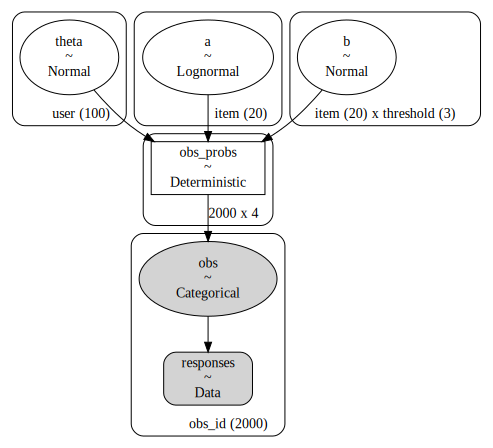

In [5]:
import numpy as np
import pymc as pm

# get index
user_idx = df_long["user"].cat.codes.to_numpy()
users = df_long["user"].cat.categories.to_numpy()
item_idx = df_long["item"].cat.codes.to_numpy()
items = df_long["item"].cat.categories.to_numpy()
responses = df_long["response"].to_numpy().astype("int32")  # 0..K-1

K = int(responses.max() + 1)
n_thresholds = K - 1

coords = {
    "user": users,
    "item": items,
    "threshold": np.arange(n_thresholds),
    "obs_id": np.arange(len(df_long)),
}

with pm.Model(coords=coords) as model:
    responses_ = pm.Data("responses", responses, dims="obs_id")

    theta = pm.Normal("theta", 0.0, 1.0, dims="user")
    a = pm.LogNormal("a", 0.0, 0.5, dims="item")
    b = pm.Normal(
        "b",
        mu=np.linspace(-1, 1, n_thresholds),
        sigma=2.0,
        dims=("item", "threshold"),
        transform=pm.distributions.transforms.ordered,
    )
    eta = a[item_idx] * theta[user_idx]

    # GRM の cutpoints: a_j * b_{jk}
    # OrderedLogistic は P(Y >= k) = sigma(eta - cutpoints_k) を計算するため、
    # Samejima のパラメタリゼーション P(Y >= k) = sigma(a*(theta - b)) に合わせるには
    # cutpoints = a * b とする必要がある（a > 0 なので順序は保たれる）
    cutpoints = a[:, None] * b

    # 観測：item ごとの cutpoints を観測ごとに参照
    pm.OrderedLogistic(
        "obs",
        eta=eta,
        cutpoints=cutpoints[item_idx],
        observed=responses_,
        dims="obs_id",
    )

pm.model_to_graphviz(model)

## Sampling

In [6]:
with model:
    idata = pm.sample(
        1000,
        tune=1000,
        chains=4,
        random_seed=42,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, a, b]
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/pytensor/tensor/subtensor.py:2486: RuntimeWarning: invalid value encountered in at
  np.add.at(x, idx, y)
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/pytensor/tensor/subtensor.py:2486: RuntimeWarning: invalid value encountered in at
  np.add.at(x, idx, y)
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/pytensor/tensor/subtensor.py:2486: RuntimeWarning: invalid value encountered in at
  np.add.at(x, idx, y)
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/pytensor/tensor/subtensor.py:2486: RuntimeWarning: invalid value encountered in at
  np.add.at(x, idx, y)
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subs

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


## Results

In [7]:
az.summary(idata, var_names=["a", "b"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[item_1],0.42,0.13,0.20,0.66,0.00,0.00,2061.52,2584.95,1.0
a[item_2],1.21,0.31,0.64,1.76,0.01,0.00,1673.33,1969.62,1.0
a[item_3],0.66,0.18,0.33,0.98,0.00,0.00,1499.35,1824.26,1.0
a[item_4],1.28,0.32,0.73,1.88,0.01,0.00,1701.34,2039.80,1.0
a[item_5],0.54,0.17,0.24,0.85,0.00,0.00,1644.15,2166.09,1.0
...,...,...,...,...,...,...,...,...,...
"b[item_19, 1]",0.39,0.16,0.08,0.68,0.00,0.00,2017.38,2370.01,1.0
"b[item_19, 2]",1.73,0.30,1.24,2.30,0.01,0.01,1599.30,1896.23,1.0
"b[item_20, 0]",-0.33,0.43,-1.15,0.44,0.01,0.01,2674.14,2033.83,1.0
"b[item_20, 1]",0.16,0.40,-0.58,0.91,0.01,0.01,4279.50,2874.29,1.0


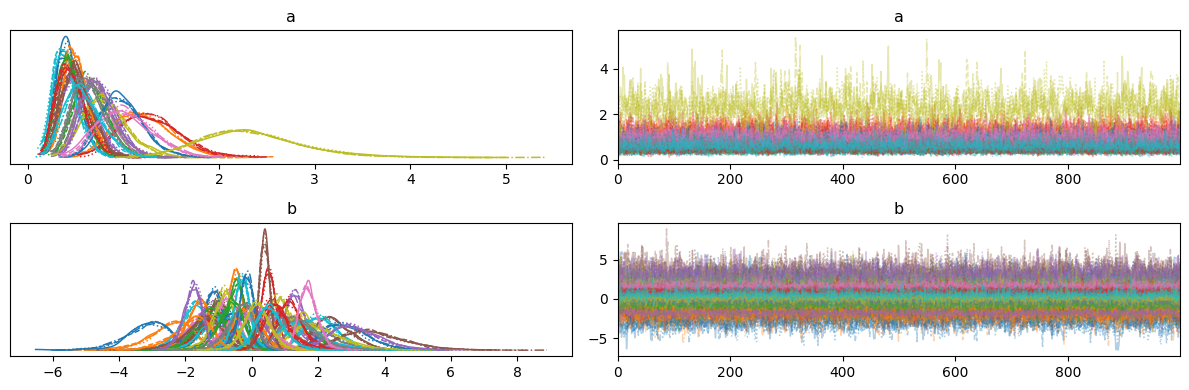

In [8]:
az.plot_trace(idata, var_names=["a", "b"], compact=True)
plt.tight_layout()
plt.show()

## Comparison: Estimated vs True Parameters

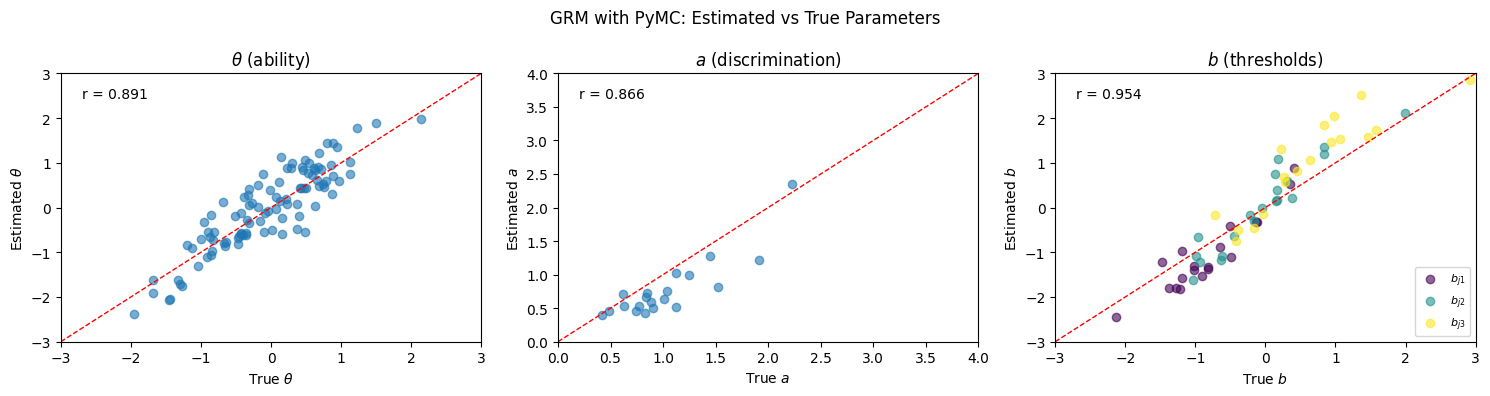

In [10]:
theta_est = idata.posterior["theta"].mean(dim=["chain", "draw"]).values  # (N,)
a_est = idata.posterior["a"].mean(dim=["chain", "draw"]).values           # (J,)
b_est = idata.posterior["b"].mean(dim=["chain", "draw"]).values           # (J, K-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# theta
axes[0].scatter(theta_true, theta_est, alpha=0.6)
axes[0].plot([-3, 3], [-3, 3], "r--", lw=1)
axes[0].set(xlim=(-3, 3), ylim=(-3, 3),
            xlabel=r"True $\theta$", ylabel=r"Estimated $\theta$",
            title=r"$\theta$ (ability)")
axes[0].text(0.05, 0.95, f"r = {np.corrcoef(theta_true, theta_est)[0,1]:.3f}",
             transform=axes[0].transAxes, va="top")

# a
axes[1].scatter(a_true, a_est, alpha=0.6)
axes[1].plot([0, 4], [0, 4], "r--", lw=1)
axes[1].set(xlim=(0, 4), ylim=(0, 4),
            xlabel=r"True $a$", ylabel=r"Estimated $a$",
            title=r"$a$ (discrimination)")
axes[1].text(0.05, 0.95, f"r = {np.corrcoef(a_true, a_est)[0,1]:.3f}",
             transform=axes[1].transAxes, va="top")

# b — all J*(K-1) threshold pairs, colored by threshold index
colors = plt.cm.viridis(np.linspace(0, 1, K - 1))
for k in range(K - 1):
    axes[2].scatter(b_true[:, k], b_est[:, k], alpha=0.6,
                    color=colors[k], label=f"$b_{{j{k+1}}}$")
axes[2].plot([-3, 3], [-3, 3], "r--", lw=1)
axes[2].set(xlim=(-3, 3), ylim=(-3, 3),
            xlabel=r"True $b$", ylabel=r"Estimated $b$",
            title=r"$b$ (thresholds)")
axes[2].legend(fontsize=8)
b_corr = np.corrcoef(b_true.ravel(), b_est.ravel())[0, 1]
axes[2].text(0.05, 0.95, f"r = {b_corr:.3f}",
             transform=axes[2].transAxes, va="top")

plt.suptitle("GRM with PyMC: Estimated vs True Parameters")
plt.tight_layout()
plt.show()